In [21]:
import pandas as pd

df_telemetry_log = pd.read_csv('telemetry_log_20260622-201715.csv', skiprows=[0])
df_telemetry_log

,timestamp,RSSI,SNR,Is_Valid_Mavlink,Package_Size,Package_Hex
0,7303,-53,9.50,1,20,FD080000000101CA00006E0000000000A60AE881
1,7376,-53,9.25,1,34,FD160000010101C90000820000009EFD06FF530F180000...
2,7428,-52,9.75,1,20,FD080000020101CA0000820000000000AB0A617B
3,7501,-51,10.25,1,34,FD160000030101C900008C0000008EFD11FF530F1900FF...
4,7574,-50,9.50,1,34,FD160000040101C90000960000007BFDF4FE530F1C00EB...
...,...,...,...,...,...,...
7800,776322,-44,9.50,1,34,FD1600006E0101C900003CB80B006AFD7CFE530F1300DB...
7801,776395,-43,10.00,1,34,FD1600006F0101C9000082B80B0073FD7FFE530F0000FC...
7802,776467,-44,9.75,1,34,FD160000700101C90000C8B80B0067FD5FFE530FFBFF07...
7803,776540,-44,9.50,1,34,FD160000710101C9000018B90B004EFD7DFE530F1300F9...


In [22]:
df_distance_log = pd.read_csv('distance_log_20260622-201715.csv')
df_distance_log

,coordinates,timestamp
0,"5°12'21.5""S 37°19'17.2""W",0
1,"5°12'23.0""S 37°19'14.6""W",97000
2,"5°12'25.7""S 37°19'10.7""W",282000
3,"5°12'28.9""S 37°19'06.3""W",404000
4,"5°12'29.5""S 37°19'05.5""W",449000
5,"5°12'30.9""S 37°19'03.4""W",498187


## Análise da Taxa de Pacotes

In [23]:
indice_tempo = pd.to_timedelta(df_telemetry_log['timestamp'], unit='ms')

df_telemetry_log['pacotes_por_segundo'] = (
    df_telemetry_log
    .set_index(indice_tempo)['timestamp']
    .rolling('1s')
    .count()
    .values
)

df_telemetry_log

,timestamp,RSSI,SNR,Is_Valid_Mavlink,Package_Size,Package_Hex,pacotes_por_segundo
0,7303,-53,9.50,1,20,FD080000000101CA00006E0000000000A60AE881,1.0
1,7376,-53,9.25,1,34,FD160000010101C90000820000009EFD06FF530F180000...,2.0
2,7428,-52,9.75,1,20,FD080000020101CA0000820000000000AB0A617B,3.0
3,7501,-51,10.25,1,34,FD160000030101C900008C0000008EFD11FF530F1900FF...,4.0
4,7574,-50,9.50,1,34,FD160000040101C90000960000007BFDF4FE530F1C00EB...,5.0
...,...,...,...,...,...,...,...
7800,776322,-44,9.50,1,34,FD1600006E0101C900003CB80B006AFD7CFE530F1300DB...,14.0
7801,776395,-43,10.00,1,34,FD1600006F0101C9000082B80B0073FD7FFE530F0000FC...,14.0
7802,776467,-44,9.75,1,34,FD160000700101C90000C8B80B0067FD5FFE530FFBFF07...,14.0
7803,776540,-44,9.50,1,34,FD160000710101C9000018B90B004EFD7DFE530F1300F9...,14.0


In [18]:
# Casos em que o pacote corrompeu
df_telemetry_log[df_telemetry_log['Is_Valid_Mavlink'] == 0]

,timestamp,RSSI,SNR,Is_Valid_Mavlink,Package_Size,Package_Hex
498,43347,-81,5.00,0,34,FC160000F20101C90040EAE8000020F783EE5323D8FF31...
2252,170554,-88,3.00,0,34,FC160000CC010DC90000D47902003E3D79FE538F1A0000...
2403,181631,-99,-0.75,0,34,F59600F86007A1C900001CA5020047FDB9FE530F1F00DE...
2452,185482,-101,-12.25,0,34,FC1791099A0101C50C007AB9DB45C87527BE753A5C7DA0...
2592,196070,-101,-9.75,0,34,A378768D068183D76CDE252D7774CD2AE6EF8167360CE9...
...,...,...,...,...,...,...
5131,572182,-102,-11.00,0,34,9D8605055F480DC39C80B648246CE3B7C9CC33250BF980...
5173,575701,-100,-9.50,0,34,F8160000A00101C900009AA80800A9FDA9FE530F090005...
6060,647225,-104,-12.00,0,34,DEF550053E0565C3AAAA20FFC1D82AF3D28EEB55515F30...
6721,697895,-102,-1.00,0,34,FC160000350101C90000DE850A00BFFD8BFE53AF180044...


/tmp/ipykernel_1146191/4069452667.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


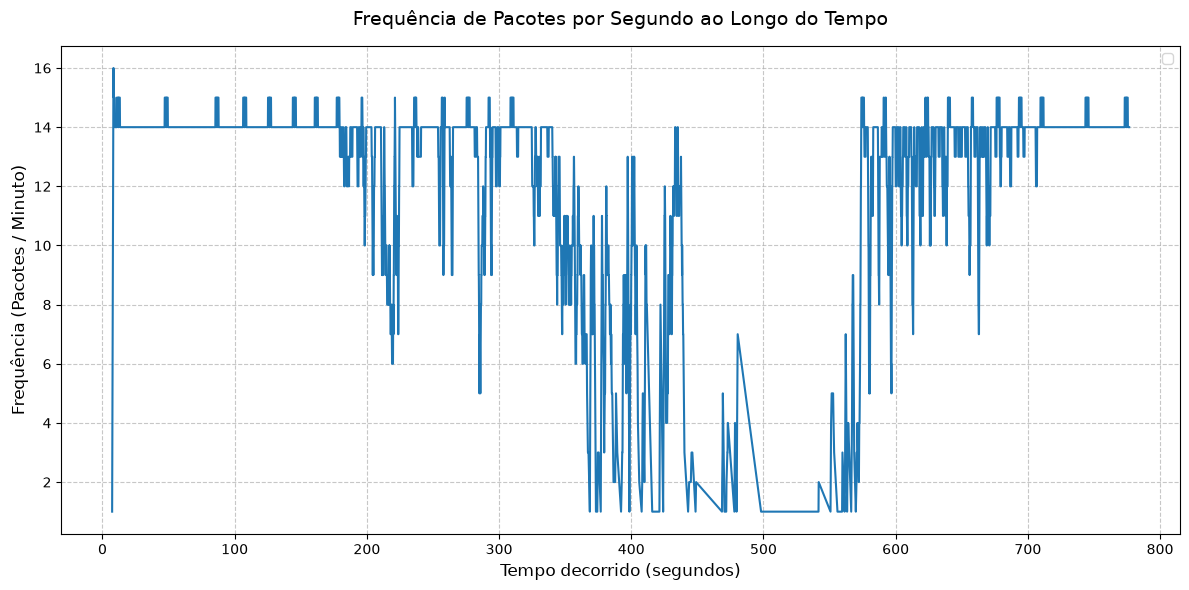

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

tempo_em_segundos = df_telemetry_log['timestamp'] / 1000

plt.plot(tempo_em_segundos, df_telemetry_log['pacotes_por_segundo'], 
         color='#1f77b4', linewidth=1.5)

plt.title('Frequência de Pacotes por Segundo ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Tempo decorrido (segundos)', fontsize=12)
plt.ylabel('Frequência (Pacotes / Segundo)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()

plt.show()

/tmp/ipykernel_1146191/2511549369.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


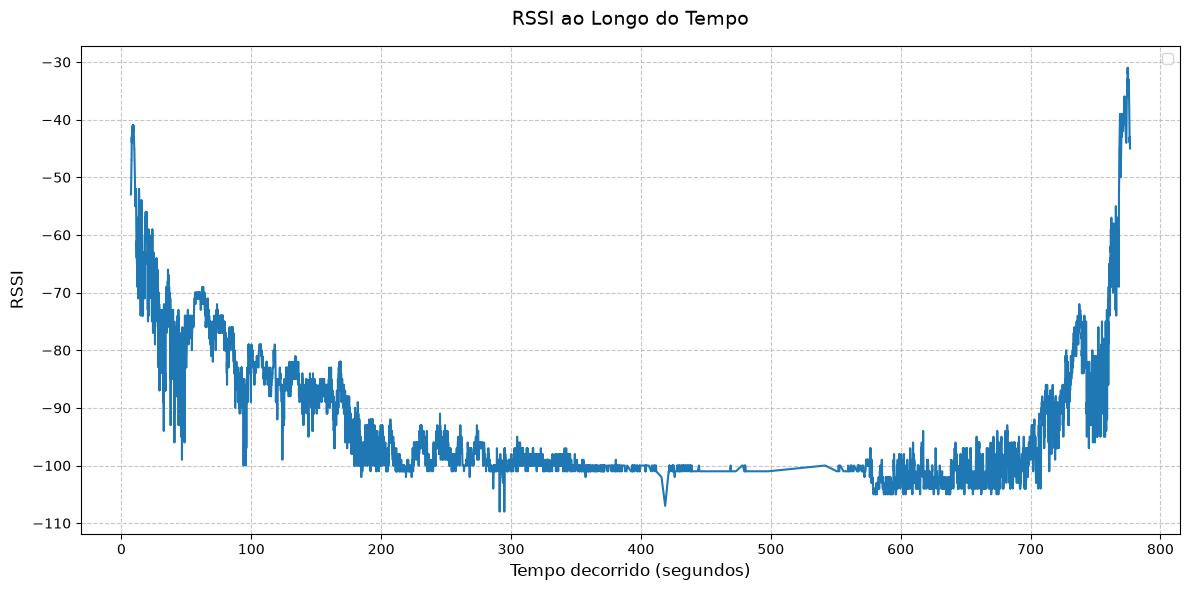

In [32]:
plt.figure(figsize=(12, 6))

tempo_em_segundos = df_telemetry_log['timestamp'] / 1000

plt.plot(tempo_em_segundos, df_telemetry_log['RSSI'], 
         color='#1f77b4', linewidth=1.5)

plt.title('RSSI ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Tempo decorrido (segundos)', fontsize=12)
plt.ylabel('RSSI', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()

plt.show()

/tmp/ipykernel_1146191/2669479905.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


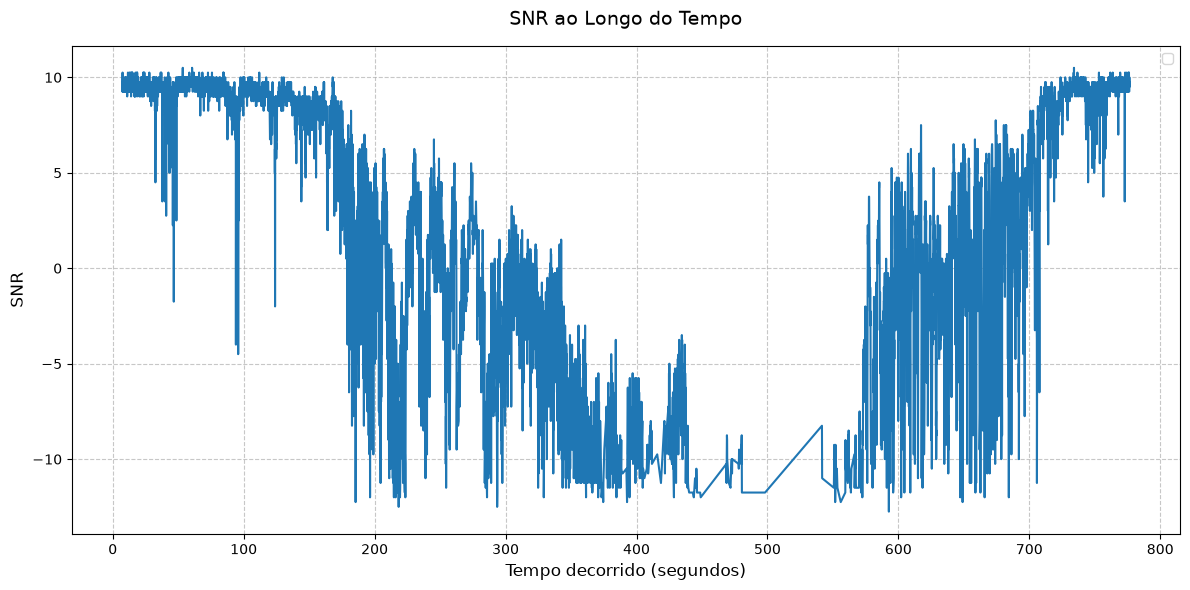

In [34]:
plt.figure(figsize=(12, 6))

tempo_em_segundos = df_telemetry_log['timestamp'] / 1000

plt.plot(tempo_em_segundos, df_telemetry_log['SNR'], 
         color='#1f77b4', linewidth=1.5)

plt.title('SNR ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Tempo decorrido (segundos)', fontsize=12)
plt.ylabel('SNR', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()

plt.show()

/tmp/ipykernel_1146191/3638864687.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


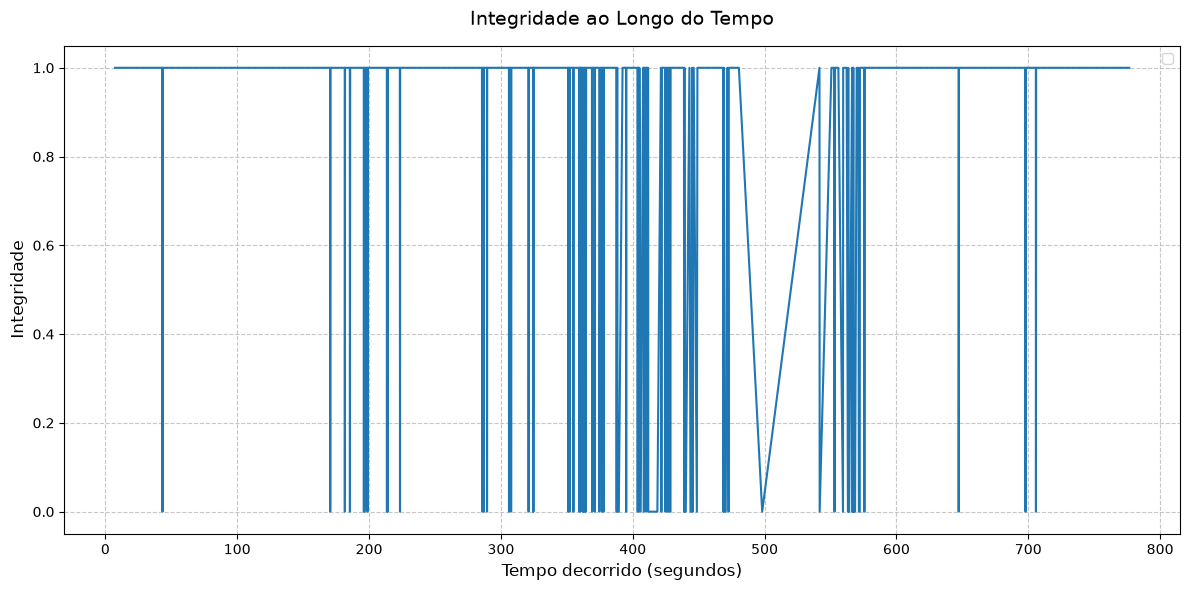

In [35]:
plt.figure(figsize=(12, 6))

tempo_em_segundos = df_telemetry_log['timestamp'] / 1000

plt.plot(tempo_em_segundos, df_telemetry_log['Is_Valid_Mavlink'], 
         color='#1f77b4', linewidth=1.5)

plt.title('Integridade ao Longo do Tempo', fontsize=14, pad=15)
plt.xlabel('Tempo decorrido (segundos)', fontsize=12)
plt.ylabel('Integridade', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()

plt.show()